In [19]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/rivalytics/saas-subscription-and-churn-analytics-dataset/ravenstack_accounts.csv
/kaggle/input/datasets/rivalytics/saas-subscription-and-churn-analytics-dataset/README.md
/kaggle/input/datasets/rivalytics/saas-subscription-and-churn-analytics-dataset/ravenstack_feature_usage.csv
/kaggle/input/datasets/rivalytics/saas-subscription-and-churn-analytics-dataset/ravenstack_support_tickets.csv
/kaggle/input/datasets/rivalytics/saas-subscription-and-churn-analytics-dataset/ravenstack_subscriptions.csv
/kaggle/input/datasets/rivalytics/saas-subscription-and-churn-analytics-dataset/ravenstack_churn_events.csv


In [20]:
import pandas as pd
import numpy as np

In [21]:
accounts = pd.read_csv('/kaggle/input/datasets/rivalytics/saas-subscription-and-churn-analytics-dataset/ravenstack_accounts.csv')
churn_events = pd.read_csv('/kaggle/input/datasets/rivalytics/saas-subscription-and-churn-analytics-dataset/ravenstack_churn_events.csv')
feature_usage = pd.read_csv('/kaggle/input/datasets/rivalytics/saas-subscription-and-churn-analytics-dataset/ravenstack_feature_usage.csv')
subscriptions = pd.read_csv('/kaggle/input/datasets/rivalytics/saas-subscription-and-churn-analytics-dataset/ravenstack_subscriptions.csv')
support_tickets = pd.read_csv('/kaggle/input/datasets/rivalytics/saas-subscription-and-churn-analytics-dataset/ravenstack_support_tickets.csv')

In [22]:
accounts.head()

,account_id,account_name,industry,country,signup_date,referral_source,plan_tier,seats,is_trial,churn_flag
0,A-2e4581,Company_0,EdTech,US,2024-10-16,partner,Basic,9,False,False
1,A-43a9e3,Company_1,FinTech,IN,2023-08-17,other,Basic,18,False,True
2,A-0a282f,Company_2,DevTools,US,2024-08-27,organic,Basic,1,False,False
3,A-1f0ac7,Company_3,HealthTech,UK,2023-08-27,other,Basic,24,True,False
4,A-ce550d,Company_4,HealthTech,US,2024-10-27,event,Enterprise,35,False,True


In [23]:
accounts['signup_date'] = pd.to_datetime(accounts['signup_date'])
accounts['signup_months'] = accounts['signup_date'].dt.to_period('M')
print(accounts['signup_date'].dtype)

datetime64[ns]


Converted datetime and grouped it by month 

In [24]:
print(accounts.isnull().sum())

account_id         0
account_name       0
industry           0
country            0
signup_date        0
referral_source    0
plan_tier          0
seats              0
is_trial           0
churn_flag         0
signup_months      0
dtype: int64


In [25]:
churn_events.head()

,churn_event_id,account_id,churn_date,reason_code,refund_amount_usd,preceding_upgrade_flag,preceding_downgrade_flag,is_reactivation,feedback_text
0,C-816288,A-c37cab,2024-10-27,pricing,4.03,False,False,False,switched to competitor
1,C-5a81e7,A-37f969,2024-06-25,support,96.45,True,False,False,NaN
2,C-a174be,A-b07346,2024-11-12,budget,0.00,False,False,False,missing features
3,C-accb39,A-1e50e0,2023-11-01,budget,54.94,False,False,False,switched to competitor
4,C-92f889,A-956988,2024-12-30,unknown,0.00,False,True,True,too expensive


In [26]:
churn_events['churn_date'] = pd.to_datetime(churn_events['churn_date'])
churn_events['feedback_text'] = churn_events['feedback_text'].fillna('No Feedback')
churn_events.head()


,churn_event_id,account_id,churn_date,reason_code,refund_amount_usd,preceding_upgrade_flag,preceding_downgrade_flag,is_reactivation,feedback_text
0,C-816288,A-c37cab,2024-10-27,pricing,4.03,False,False,False,switched to competitor
1,C-5a81e7,A-37f969,2024-06-25,support,96.45,True,False,False,No Feedback
2,C-a174be,A-b07346,2024-11-12,budget,0.00,False,False,False,missing features
3,C-accb39,A-1e50e0,2023-11-01,budget,54.94,False,False,False,switched to competitor
4,C-92f889,A-956988,2024-12-30,unknown,0.00,False,True,True,too expensive


In [35]:
df_master = pd.merge(accounts, churn_events, on= 'account_id', how= 'left')
df_master['is_active'] = df_master['churn_date'].isnull()
print("Churn Rate by Plan")
print(df_master.groupby('plan_tier')['is_active'].mean())

Churn Rate by Plan
plan_tier
Basic         0.227468
Enterprise    0.190871
Pro           0.178832
Name: is_active, dtype: float64


By merging customer accounts data with churn event records, i have isolated the Retention rate across different subsciption tiers


In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

/tmp/ipykernel_57/3305453820.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=churn_reasons.values, y=churn_reasons.index, palette='magma', legend=False)


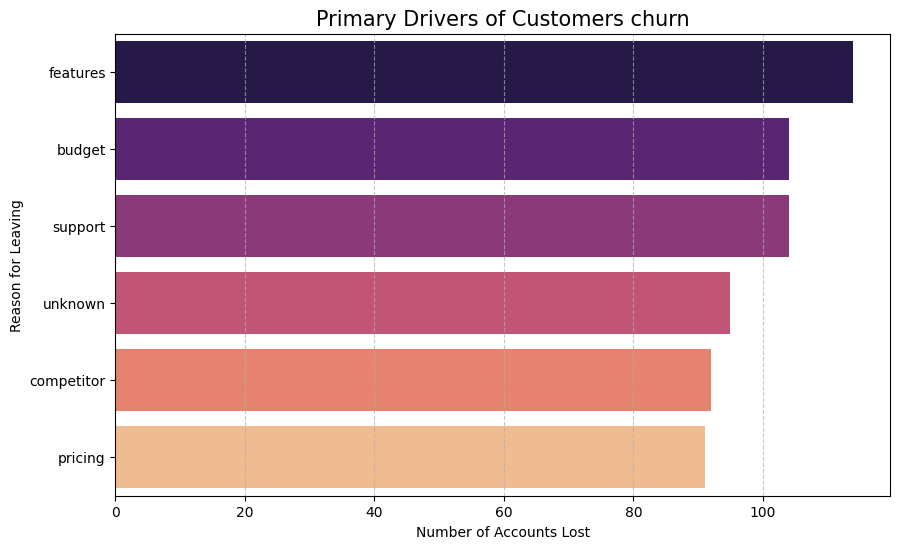

In [40]:
churn_reasons = df_master['reason_code'].value_counts()

plt.figure(figsize=(10,6))
sns.barplot(x=churn_reasons.values, y=churn_reasons.index, palette='magma', legend=False)

plt.title('Primary Drivers of Customers churn', fontsize=15)
plt.xlabel('Number of Accounts Lost', fontsize=10)
plt.ylabel('Reason for Leaving', fontsize=10)
plt.grid(axis='x',linestyle='--', alpha=0.7)

plt.show()

The graph identifies Product Feature and Budget as the primary catalysts for customer attrition
feature: The high rate of "feature" as a churn reason suggests that the current product roadmap may not be aligned with user expectation
budget = related churn indicates a potential opportunity for more flexible pricing tiers or temporary discount incentives to prevent total account loss.

while "Competitor" churn is lower, it remains consistent threat that requires ongoing market benchmarking.

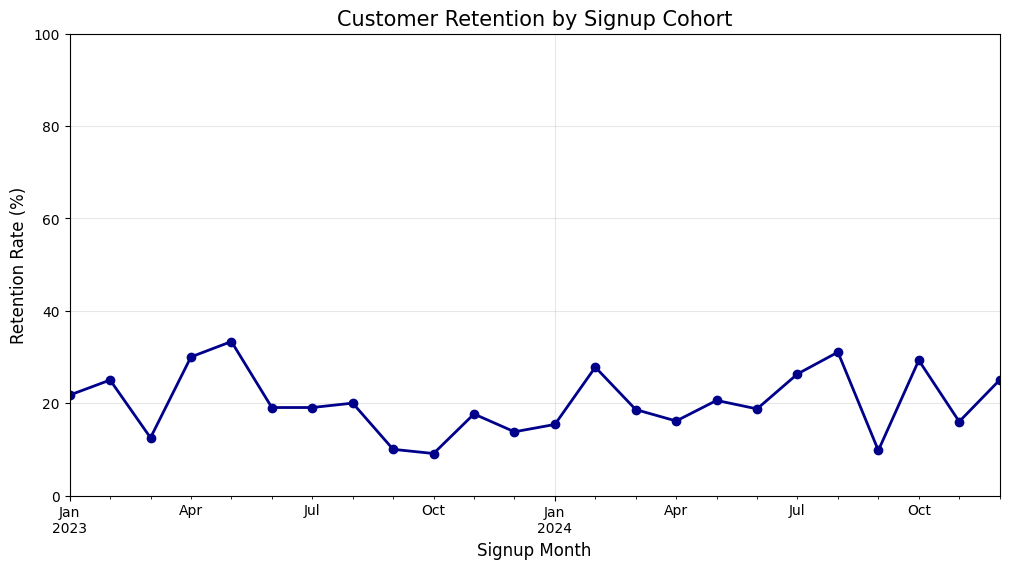

In [41]:

df_master['signup_month'] = pd.to_datetime(df_master['signup_date']).dt.to_period('M')
cohort_analysis = df_master.groupby('signup_month')['is_active'].mean() * 100


plt.figure(figsize=(12, 6))
cohort_analysis.plot(kind='line', marker='o', color='darkblue', linewidth=2)

plt.title('Customer Retention by Signup Cohort', fontsize=15)
plt.xlabel('Signup Month', fontsize=12)
plt.ylabel('Retention Rate (%)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.ylim(0, 100) 

plt.show()


The retention trend line highlights significant month to month volatility, with retention rates fluctuating between 5% and 35% across various signup cohorts. While there are noticeable peaks in late 2023 and mid 2024 likely corresponding to successful feature launches or marketing pushes the overall baseline remains around 20%. The sharp dips in late 2024 identify specific cohorts that may have faced onboarding friction or technical bugs, marking them as high-priority groups for re-engagement campaigns.